In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [3]:
df['date'] = pd.to_datetime("01-"+df['month'].astype(str)+'-'+df['year'].astype(str))
df.set_index('date',inplace=True)
df.head()

,year,month,passengers
date,,,
1949-01-01,1949,Jan,112
1949-02-01,1949,Feb,118
1949-03-01,1949,Mar,132
1949-04-01,1949,Apr,129
1949-05-01,1949,May,121


<Axes: xlabel='date', ylabel='passengers'>

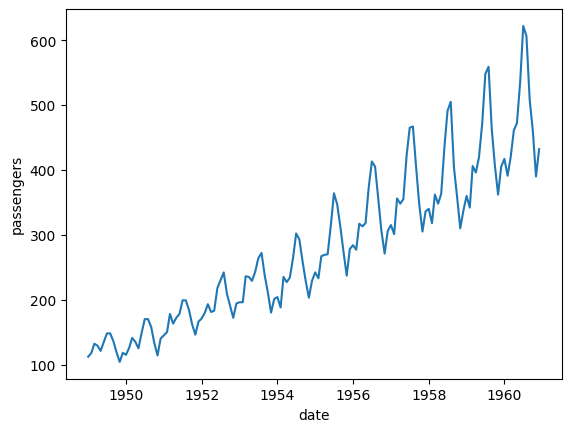

In [4]:
sns.lineplot(data=df,x=df.index,y=df.passengers)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 3.9 KB


## Lstm

In [7]:
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['passengers']])

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

2024-06-19 11:55:49.738245: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
# Define sequence length
sequence_length = 7  # Example: Use the past 7 days to predict the next day

# Create sequences
X, y = create_sequences(scaled_data, sequence_length)

# Split the data into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

from tensorflow.keras.callbacks import EarlyStopping

#Early stopping to avoid overfitting of model
early_stop=EarlyStopping(monitor='loss',mode='min', verbose=1, patience=15, restore_best_weights=True)

# Define the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f"Mean Squared Error: {mse}")

Epoch 1/100
4/4 [==============================] - 4s 12ms/step - loss: 0.1115
Epoch 2/100
4/4 [==============================] - 0s 10ms/step - loss: 0.0644
Epoch 3/100
4/4 [==============================] - 0s 9ms/step - loss: 0.0289
Epoch 4/100
4/4 [==============================] - 0s 9ms/step - loss: 0.0159
Epoch 5/100
4/4 [==============================] - 0s 7ms/step - loss: 0.0205
Epoch 6/100
4/4 [==============================] - 0s 9ms/step - loss: 0.0164
Epoch 7/100
4/4 [==============================] - 0s 15ms/step - loss: 0.0126
Epoch 8/100
4/4 [==============================] - 0s 9ms/step - loss: 0.0132
Epoch 9/100
4/4 [==============================] - 0s 9ms/step - loss: 0.0129
Epoch 10/100
4/4 [==============================] - 0s 8ms/step - loss: 0.0115
Epoch 11/100
4/4 [==============================] - 0s 9ms/step - loss: 0.0105
Epoch 12/100
4/4 [==============================] - 0s 9ms/step - loss: 0.0102
Epoch 13/100
4/4 [==============================] - 0s 9ms

1/1 [==============================] - 1s 844ms/step


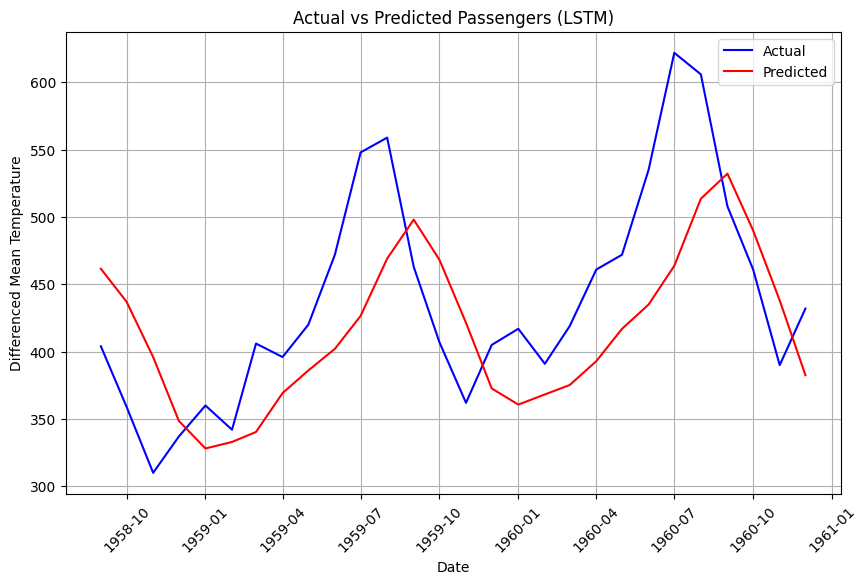

In [9]:
# Predict on test data
y_pred_scaled = model.predict(X_test)

# Inverse transform the scaled predicted and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(df.index[-len(y_actual):], y_actual, color='blue', label='Actual')
plt.plot(df.index[-len(y_pred):], y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted Passengers (LSTM)')
plt.xlabel('Date')
plt.ylabel('Differenced Mean Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [10]:
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 57.762
MSE: 4447.731
RMSE: 66.691


____________________________________________________________________________

____________________________________________________________________________

____________________________________________________________________________

In [11]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=True))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [12]:
# Train the model
model.fit(X_train, y_train, epochs=1000, batch_size=32, callbacks=[early_stop])

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f"Mean Squared Error: {mse}")

Epoch 1/1000
4/4 [==============================] - 11s 23ms/step - loss: 0.1048
Epoch 2/1000
4/4 [==============================] - 0s 21ms/step - loss: 0.0834
Epoch 3/1000
4/4 [==============================] - 0s 21ms/step - loss: 0.0624
Epoch 4/1000
4/4 [==============================] - 0s 20ms/step - loss: 0.0530
Epoch 5/1000
4/4 [==============================] - 0s 19ms/step - loss: 0.0511
Epoch 6/1000
4/4 [==============================] - 0s 20ms/step - loss: 0.0471
Epoch 7/1000
4/4 [==============================] - 0s 21ms/step - loss: 0.0458
Epoch 8/1000
4/4 [==============================] - 0s 20ms/step - loss: 0.0443
Epoch 9/1000
4/4 [==============================] - 0s 20ms/step - loss: 0.0425
Epoch 10/1000
4/4 [==============================] - 0s 19ms/step - loss: 0.0415
Epoch 11/1000
4/4 [==============================] - 0s 20ms/step - loss: 0.0408
Epoch 12/1000
4/4 [==============================] - 0s 21ms/step - loss: 0.0399
Epoch 13/1000
4/4 [=================

1/1 [==============================] - 2s 2s/step
Shape of y_pred_scaled: (28, 7, 1)
Length of y_actual: 28
Length of y_pred: 196


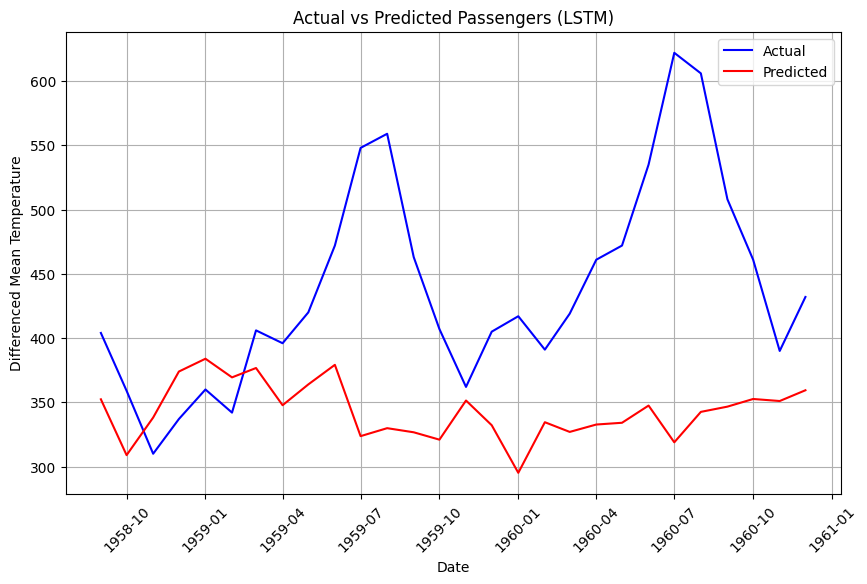

In [13]:
# Predict on test data
y_pred_scaled = model.predict(X_test)
print(f"Shape of y_pred_scaled: {y_pred_scaled.shape}")

# Ensure y_pred_scaled is reshaped to 2D array
y_pred_scaled = y_pred_scaled.reshape(-1, 1)

# Inverse transform the scaled predicted and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Check the lengths of y_pred and y_actual
print(f"Length of y_actual: {len(y_actual)}")
print(f"Length of y_pred: {len(y_pred)}")

# Ensure they have the same length for plotting
min_length = min(len(y_actual), len(y_pred))
y_actual = y_actual[:min_length]
y_pred = y_pred[:min_length]

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(df.index[-len(y_actual):], y_actual, color='blue', label='Actual')
plt.plot(df.index[-len(y_pred):], y_pred, color='red', label='Predicted')  # Use len(y_actual) here
plt.title('Actual vs Predicted Passengers (LSTM)')
plt.xlabel('Date')
plt.ylabel('Differenced Mean Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [14]:
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 102.700
MSE: 16455.973
RMSE: 128.281


_________________________________________________________________

_________________________________________________________________

_________________________________________________________________